In [1]:
from langchain_openai import ChatOpenAI
import os
#from langchain_google_genai import ChatGoogleGenerativeAI

base_url= os.getenv("AICREDITS_BASE_URL")
api_key = os.getenv("AICREDITS_API_KEY")

In [2]:
llm = ChatOpenAI(
    model="google/gemini-2.5-flash",
    api_key=api_key,
    base_url=base_url,
    #temperature=2.0
)

# Test the model
response = llm.invoke("Hello!")
print(response.content)


Hello there! How can I help you today?


In [3]:
import math
import numexpr as ne
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun


search = DuckDuckGoSearchRun()

@tool
def calculator(expression: str) -> str:
    """Calculates a single mathematical expression, incl. complex numbers.

    Always add * to operations, examples:
      73i -> 73*i
      7pi**2 -> 7*pi**2
    """
    math_constants = {"pi": math.pi, "i": 1j, "e": math.exp}
    result = ne.evaluate(expression.strip(), local_dict=math_constants)
    return str(result)


llm_with_tools = llm.bind_tools([search, calculator])

C:\Users\Shivachetan Ulavi\AppData\Local\Temp\ipykernel_16760\2299295658.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [5]:
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import MessagesState, StateGraph, START, END

def invoke_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(MessagesState)
builder.add_node("invoke_llm", invoke_llm)
builder.add_node("tools", ToolNode([search, calculator]))

builder.add_edge(START, "invoke_llm")
builder.add_conditional_edges("invoke_llm", tools_condition)
builder.add_edge("tools", "invoke_llm")
builder.add_edge("tools", END)
builder.add_edge("invoke_llm", END)
graph = builder.compile()

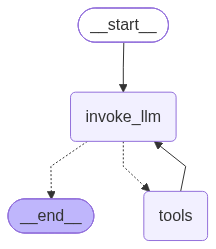

In [6]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
for e in graph.stream({"messages": ("human", "how much is 23 + 46")}):
    print(e)

{'invoke_llm': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 152, 'total_tokens': 234, 'completion_tokens_details': None, 'prompt_tokens_details': None, 'cost': 0.028147953026239205, 'cost_details': {'completion_cost_inr': 0.02302605894006, 'prompt_cost_inr': 0.0051218940861792}, 'latency_ms': 1400}, 'model_provider': 'openai', 'model_name': 'gemini-2.5-flash', 'system_fingerprint': '', 'id': 'chatcmpl-gemini', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a07ac9-e2ca-71a3-a05d-9e341ab89875-0', tool_calls=[{'name': 'calculator', 'args': {'expression': '23 + 46'}, 'id': 'call_calculator_0', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 152, 'output_tokens': 18, 'total_tokens': 234, 'input_token_details': {}, 'output_token_details': {}})]}}
{'tools': {'messages': [ToolMessage(content='69', name='calculator', id='2cbeb1a3-b297-4d15-8da5-

### Using custom tools to easily extract dates from user input

In [9]:
examples = [
  "I signed my contract 2 years ago",
  "I started the deal with your company in February last year",
  "Our contract started on March 24th two years ago"
]

In [10]:
from datetime import date, timedelta

@tool
def get_date(year: int, month: int = 1, day: int = 1) -> date:
    """Returns a date object given year, month and day.

      Default month and day are 1 (January) and 1.
      Examples in YYYY-MM-DD format:
        2023-07-27 -> date(2023, 7, 27)
        2022-12-15 -> date(2022, 12, 15)
        March 2022 -> date(2022, 3)
        2021 -> date(2021)
    """
    return date(year, month, day).isoformat()

@tool
def time_difference(days: int=0, weeks: int =0, months: int=0, years: int=0) -> date:
    """Returns a date given a difference in days, weeks, months and years relative to the current date.
    By default, dayss, weeks, months and years are 0.
    Examples:
      two weeks ago -> time_difference(weeks=2)
      last year -> time_difference(years=1)
      """
    dt = date.today() - timedelta(days=days, weeks=weeks)
    new_year = dt.year+(dt.month-months) // 12 - years
    new_month = (dt.month-months) % 12
    return dt.replace(year=new_year, month=new_month)

In [11]:
from langgraph.prebuilt import create_react_agent

agent = create_react_agent(
    llm, [get_date, time_difference], prompt="Extract the starting date of a contract. Current year is 2026.")

for example in examples:
    result = agent.invoke({"messages": [("user", example)]})
    print(example, result["messages"][-1].content)

C:\Users\Shivachetan Ulavi\AppData\Local\Temp\ipykernel_16760\4187603866.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


I signed my contract 2 years ago The starting date of your contract was 2024-01-01.

I started the deal with your company in February last year The starting date of the contract was February 1, 2025.
Our contract started on March 24th two years ago The contract started on 2024-03-24.


In [15]:
for e in agent.stream({"messages": [("user", examples[2])]}):
  print(e)

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 375, 'total_tokens': 842, 'completion_tokens_details': None, 'prompt_tokens_details': None, 'cost': 0.14377246557696002, 'cost_details': {'completion_cost_inr': 0.13113621371961004, 'prompt_cost_inr': 0.012636251857350001}, 'latency_ms': 3423}, 'model_provider': 'openai', 'model_name': 'gemini-2.5-flash', 'system_fingerprint': '', 'id': 'chatcmpl-gemini', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a07ada-eecd-77e1-924f-0df848e68fd8-0', tool_calls=[{'name': 'get_date', 'args': {'day': 24, 'month': 3, 'year': 2024}, 'id': 'call_get_date_0', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 375, 'output_tokens': 29, 'total_tokens': 842, 'input_token_details': {}, 'output_token_details': {}})]}}
{'tools': {'messages': [ToolMessage(content='2024-03-24', name='get_date', id='3e9b57b7-38

In [13]:
result["messages"][-1].content

'The contract started on 2024-03-24.'